In [31]:
# =============================================
# IMPORTY
# =============================================
import os
import sys
import math
import time

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from torch import nn
from pfns import utils
from pfns.model import bar_distribution

# Nastav working directory na kořen projektu
_nb_dir = os.path.abspath('')
if os.path.basename(_nb_dir) in ('experiments', 'examples', 'train'):
    os.chdir(os.path.dirname(_nb_dir))
sys.path.insert(0, os.path.join(os.getcwd(), 'PFNs'))
print(f"✓ Working directory: {os.getcwd()}")

from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors import Batch
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"✓ Device: {device}")
print(f"✓ PyTorch: {torch.__version__}")

✓ Working directory: /Users/ruslanguliev/VU_RG
✓ Device: mps
✓ PyTorch: 2.10.0


In [32]:
# =============================================
# NAČTENÍ MODELU
# =============================================

# DŮLEŽITÉ: get_batch_for_gp_random_hps musí být definována PŘED torch.load,
# protože checkpoint obsahuje přímou referenci na tuto funkci v pickle datech.
def get_batch_for_gp_random_hps(batch_size, seq_len, num_features, device="cpu", hyperparameters=None, **kwargs):
    random_hps = {
        "lengthscale": float(np.random.uniform(0.05, 1.0)),
        "outputscale": float(np.random.lognormal(0, 0.5)),
        "noise":       float(10 ** np.random.uniform(-3, -2)),
    }
    return get_batch_for_gp(batch_size, seq_len, num_features, device=device, hyperparameters=random_hps, **kwargs)

# checkpoint_path = os.path.join("models", "pfn_rand_hps_latest_epoch_500.pth")
checkpoint_path = os.path.join("models", "pfn_rand_hps_6layer.pth")

print(f"Loading: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

config = checkpoint["config"]

# Podpora obou formátů checkpointu:
#   Starý formát: config["num_features"], config["max_dataset_size"], checkpoint["criterion"]
#   Nový formát (MainConfig): config["priors"][...], config["batch_shape_sampler"][...], config["model"]["criterion"]["borders"]
if "num_features" in config:
    # Starý formát
    num_features     = config["num_features"]
    max_dataset_size = config["max_dataset_size"]
    criterion        = checkpoint["criterion"]
    borders          = criterion.borders.tolist()
    prior_hps        = config.get("hps", {"noise": 1e-3, "outputscale": 1.0, "lengthscale": 0.3})
    get_batch_fn     = get_batch_for_gp
    prior_kwargs     = {"num_features": num_features, "hyperparameters": prior_hps}
else:
    # Nový formát (MainConfig)
    num_features     = config["priors"][0]["prior_kwargs"]["num_features"]
    max_dataset_size = config["batch_shape_sampler"]["max_seq_len"]
    borders          = config["model"]["criterion"]["borders"]
    get_batch_fn     = get_batch_for_gp_random_hps
    prior_kwargs     = {"num_features": num_features, "hyperparameters": {}}
    criterion        = None  # rekonstruujeme po dummy tréninku

model_config = MainConfig(
    priors=[AdhocPriorConfig(
        get_batch_methods=[get_batch_fn],
        prior_kwargs=prior_kwargs
    )],
    optimizer=OptimizerConfig("adamw", lr=0.0003),
    model=TransformerConfig(
        criterion=BarDistributionConfig(full_support=True, borders=borders),
        emsize=512,
        nhead=8,
        nhid=1024,
        nlayers=6,
        features_per_group=1,
        attention_between_features=False,
        encoder=EncoderConfig(
            constant_normalization_mean=0.5,
            constant_normalization_std=math.sqrt(1/12)
        )
    ),
    batch_shape_sampler=BatchShapeSamplerConfig(
        batch_size=2,
        max_seq_len=max_dataset_size,
        min_num_features=num_features,
        max_num_features=num_features
    ),
    epochs=1,
    steps_per_epoch=1,
    num_workers=0,
)

print("Vytvářím strukturu modelu...")
dummy_result = train(model_config, device=device, reusable_config=False)
loaded_model = dummy_result["model"]

loaded_model.load_state_dict(checkpoint["model_state_dict"])
if criterion is not None:
    loaded_model.criterion = criterion
loaded_model.to(device)
loaded_model.eval()

# =============================================
# GLOBÁLNÍ NASTAVENÍ
# =============================================
# Defaultní HP pro experimenty
hps = {"noise": 1e-3, "outputscale": 1.0, "lengthscale": 0.3}
hps_demo = hps

def reset_seed():
    import random
    s = random.randint(0, 2**32 - 1)
    torch.manual_seed(s)
    np.random.seed(s % (2**31))
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

def get_batch_cpu(batch_size, seq_len, num_features, hyperparameters, device):
    """Wrapper: generuje data na CPU (správný seed), přesune na device."""
    batch = get_batch_for_gp(batch_size, seq_len, num_features,
                              device="cpu", hyperparameters=hyperparameters)
    return Batch(x=batch.x.to(device), y=batch.y.to(device), target_y=batch.target_y.to(device))

# Reset seedu HNED po dummy tréninku
reset_seed()

# print(f"✓ Model načten (epocha {checkpoint['epoch']})")
print(f"  Parametrů: {sum(p.numel() for p in loaded_model.parameters()) / 1e6:.2f}M")
print(f"  Defaultní HP: {hps}")

Loading: models/pfn_rand_hps_6layer.pth
Vytvářím strukturu modelu...
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<pfns.priors.fast_gp.get_batch (batch_size, seq_len, num_features, device='mps', hyperparameters=None, equidistant_x=False, fix_x=None, **kwargs)
), num_features=1, hyperparameters={'noise': 0.0001, 'outputscale': 1.0, 'lengthscale': 0.3}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=120, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<pfns.priors.fast_gp.get_batch (batch_size,

/Users/ruslanguliev/VU_RG/PFNs/pfns/train.py:238: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler() if c.train_mixed_precision else None


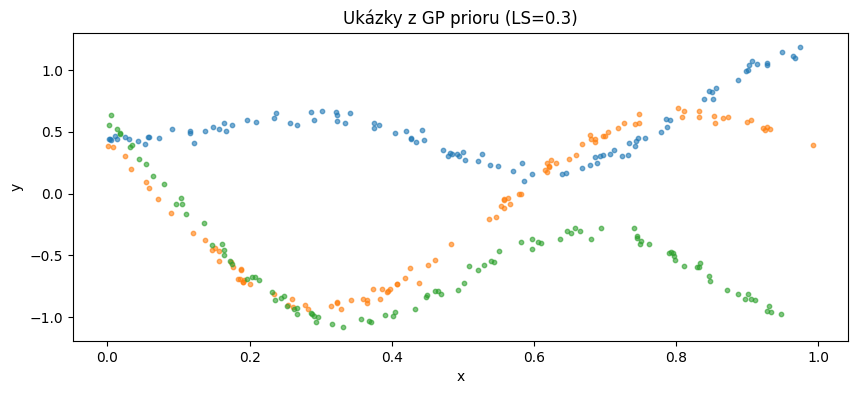

Batch shapes: x=torch.Size([3, 100, 1]), y=torch.Size([3, 100])


In [33]:
# =============================================
# GP PRIOR - Sampling funkce
# =============================================

batch = get_batch_for_gp(batch_size=3, seq_len=100, num_features=1, hyperparameters=hps_demo)

plt.figure(figsize=(10, 4))
for i in range(len(batch.x)):
    plt.scatter(batch.x[i, :, 0].cpu().numpy(), batch.y[i, :].cpu().numpy(), alpha=0.6, s=10)
plt.title('Ukázky z GP prioru (LS=0.3)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
print(f"Batch shapes: x={batch.x.shape}, y={batch.y.shape}")

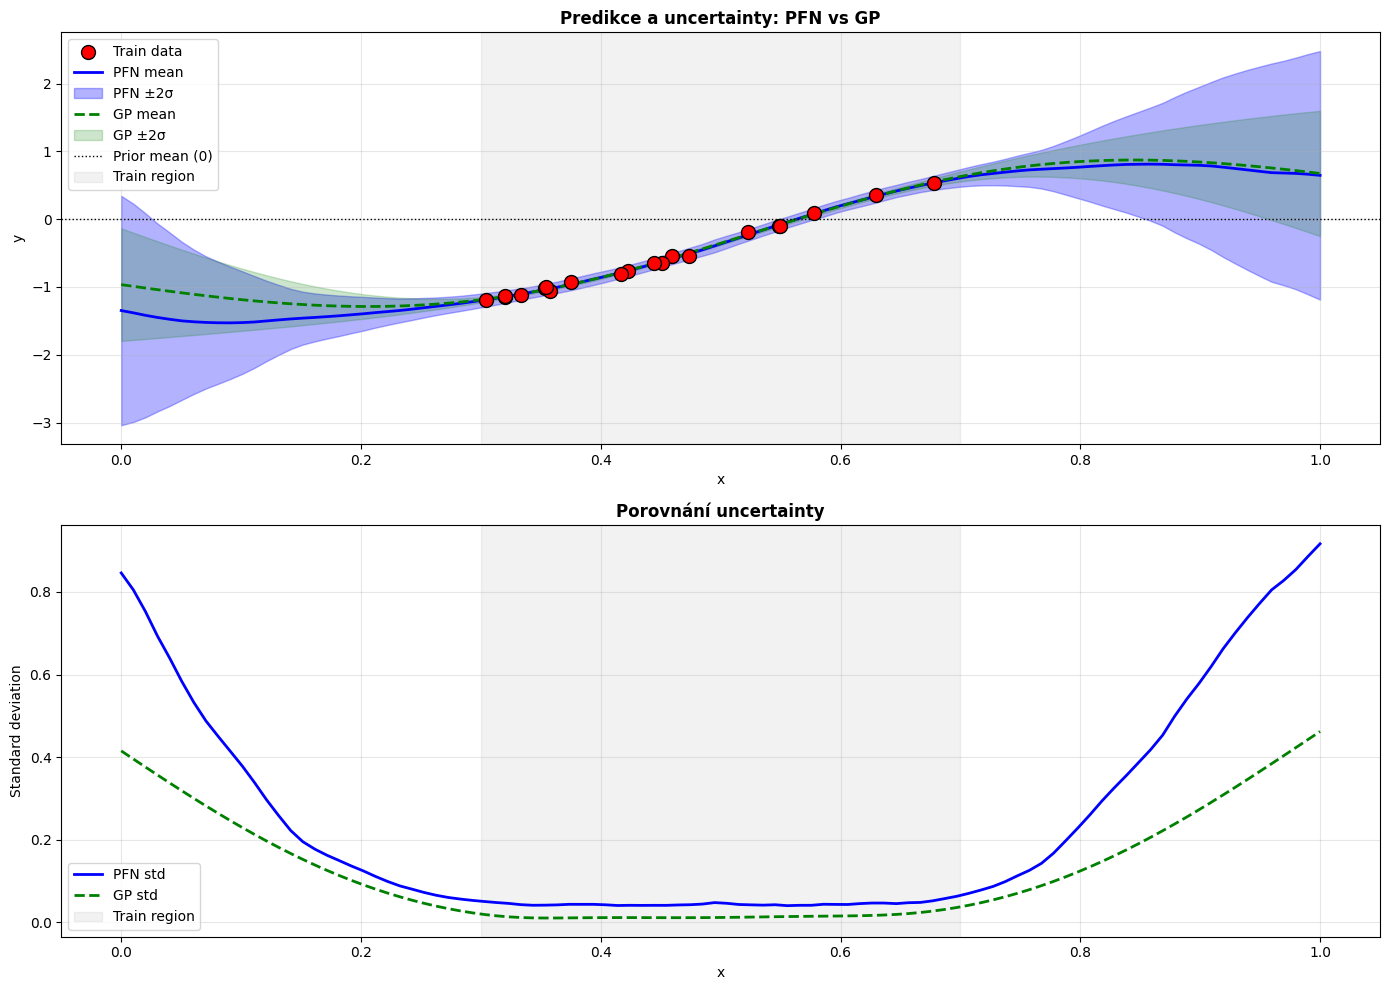


=== TEST 1: Konvergence mean funkce ===
Trial 0: train_mean=-0.60, PFN far=-0.36, GP far=-0.17
Trial 1: train_mean=-0.79, PFN far=-1.17, GP far=-1.29
Trial 2: train_mean=1.22, PFN far=0.25, GP far=0.29
Trial 3: train_mean=-0.39, PFN far=0.50, GP far=0.40
Trial 4: train_mean=0.82, PFN far=1.01, GP far=1.24

=== TEST 2: Správnost variance ===
Trial 0: corr=0.9894, MSE(std)=0.031905, ratio PFN=12.1, GP=21.7
Trial 1: corr=0.9963, MSE(std)=0.013738, ratio PFN=8.5, GP=20.7
Trial 2: corr=0.9757, MSE(std)=0.008446, ratio PFN=6.9, GP=25.4
Trial 3: corr=0.9845, MSE(std)=0.026191, ratio PFN=11.1, GP=28.8
Trial 4: corr=0.9588, MSE(std)=0.027711, ratio PFN=10.5, GP=24.2


In [34]:
# =============================================
# EXPERIMENT 1: Konvergence k prioru a variance
# =============================================

def test_prior_convergence_and_variance(model, hps, n_trials=10):
    reset_seed()
    results = []

    for trial in range(n_trials):
        batch = get_batch_cpu(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps, device=device)

        train_mask = (batch.x[0, :, 0] >= 0.3) & (batch.x[0, :, 0] <= 0.7)
        train_indices = torch.where(train_mask)[0][:20]

        train_x = batch.x[0, train_indices]
        train_y = batch.y[0, train_indices]
        test_x = torch.linspace(0, 1, 100).unsqueeze(1).to(batch.x.device)

        with torch.no_grad():
            logits = model(train_x[None], train_y[None], test_x[None])
        pfn_means = model.criterion.mean(logits)[0].cpu().numpy()
        pfn_std = np.sqrt(model.criterion.variance(logits)[0].cpu().numpy())

        kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
        gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
        gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
        gp_mean, gp_std = gp.predict(test_x.cpu().numpy(), return_std=True)

        results.append({
            'test_x': test_x.cpu().numpy().flatten(),
            'train_x': train_x.cpu().numpy().flatten(),
            'train_y': train_y.cpu().numpy().flatten(),
            'pfn_mean': pfn_means, 'pfn_std': pfn_std,
            'gp_mean': gp_mean, 'gp_std': gp_std,
        })

    return results


results = test_prior_convergence_and_variance(loaded_model, hps, n_trials=5)
res = results[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
ax.scatter(res['train_x'], res['train_y'], c='red', s=100, zorder=10, label='Train data', edgecolors='black')
ax.plot(res['test_x'], res['pfn_mean'], 'b-', lw=2, label='PFN mean')
ax.fill_between(res['test_x'], res['pfn_mean']-2*res['pfn_std'], res['pfn_mean']+2*res['pfn_std'],
                 alpha=0.3, color='blue', label='PFN ±2σ')
ax.plot(res['test_x'], res['gp_mean'], 'g--', lw=2, label='GP mean')
ax.fill_between(res['test_x'], res['gp_mean']-2*res['gp_std'], res['gp_mean']+2*res['gp_std'],
                 alpha=0.2, color='green', label='GP ±2σ')
ax.axhline(y=0, color='black', linestyle=':', lw=1, label='Prior mean (0)')
ax.axvspan(0.3, 0.7, alpha=0.1, color='gray', label='Train region')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Predikce a uncertainty: PFN vs GP', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(res['test_x'], res['pfn_std'], 'b-', lw=2, label='PFN std')
ax.plot(res['test_x'], res['gp_std'], 'g--', lw=2, label='GP std')
ax.axvspan(0.3, 0.7, alpha=0.1, color='gray', label='Train region')
ax.set_xlabel('x'); ax.set_ylabel('Standard deviation')
ax.set_title('Porovnání uncertainty', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\n=== TEST 1: Konvergence mean funkce ===")
for i, res in enumerate(results):
    far_mask = (res['test_x'] < 0.2) | (res['test_x'] > 0.8)
    near_mask = (res['test_x'] >= 0.4) & (res['test_x'] <= 0.6)
    train_mean = np.mean(res['train_y'])
    print(f"Trial {i}: train_mean={train_mean:.2f}, "
          f"PFN far={np.mean(res['pfn_mean'][far_mask]):.2f}, "
          f"GP far={np.mean(res['gp_mean'][far_mask]):.2f}")

print("\n=== TEST 2: Správnost variance ===")
for i, res in enumerate(results):
    corr = np.corrcoef(res['pfn_std'], res['gp_std'])[0, 1]
    mse_std = np.mean((res['pfn_std'] - res['gp_std'])**2)
    far_mask = (res['test_x'] < 0.2) | (res['test_x'] > 0.8)
    near_mask = (res['test_x'] >= 0.4) & (res['test_x'] <= 0.6)
    pfn_ratio = np.mean(res['pfn_std'][far_mask]) / np.mean(res['pfn_std'][near_mask])
    gp_ratio = np.mean(res['gp_std'][far_mask]) / np.mean(res['gp_std'][near_mask])
    print(f"Trial {i}: corr={corr:.4f}, MSE(std)={mse_std:.6f}, "
          f"ratio PFN={pfn_ratio:.1f}, GP={gp_ratio:.1f}")

# Interpretace Experimentu 1

* Modrá (PFN) = predikce modelu, který musel sám odhadnout HP z dat.
* Zelená (GP) = predikce GP se znalostí správných HP (oracle).
* Porovnáváme tvar a škálu uncertainty.

In [35]:
# =============================================
# DATASET — spusť pro nová náhodná data
# =============================================
# Sdílený batch pro Experimenty 2 a 3

reset_seed()

n_context = 20
seq_len = 50

batch = get_batch_for_gp(batch_size=1, seq_len=seq_len, num_features=1, hyperparameters=hps)
train_x = batch.x[0, :n_context]
train_y = batch.y[0, :n_context]
test_x  = batch.x[0]

print(f"Nový dataset: {n_context} train bodů, {seq_len - n_context} test bodů")

Nový dataset: 20 train bodů, 30 test bodů


Počet vrstev: 6
Vrstva 0: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 1: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 2: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 3: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 4: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 5: attention shape = torch.Size([1, 1, 8, 70, 70])


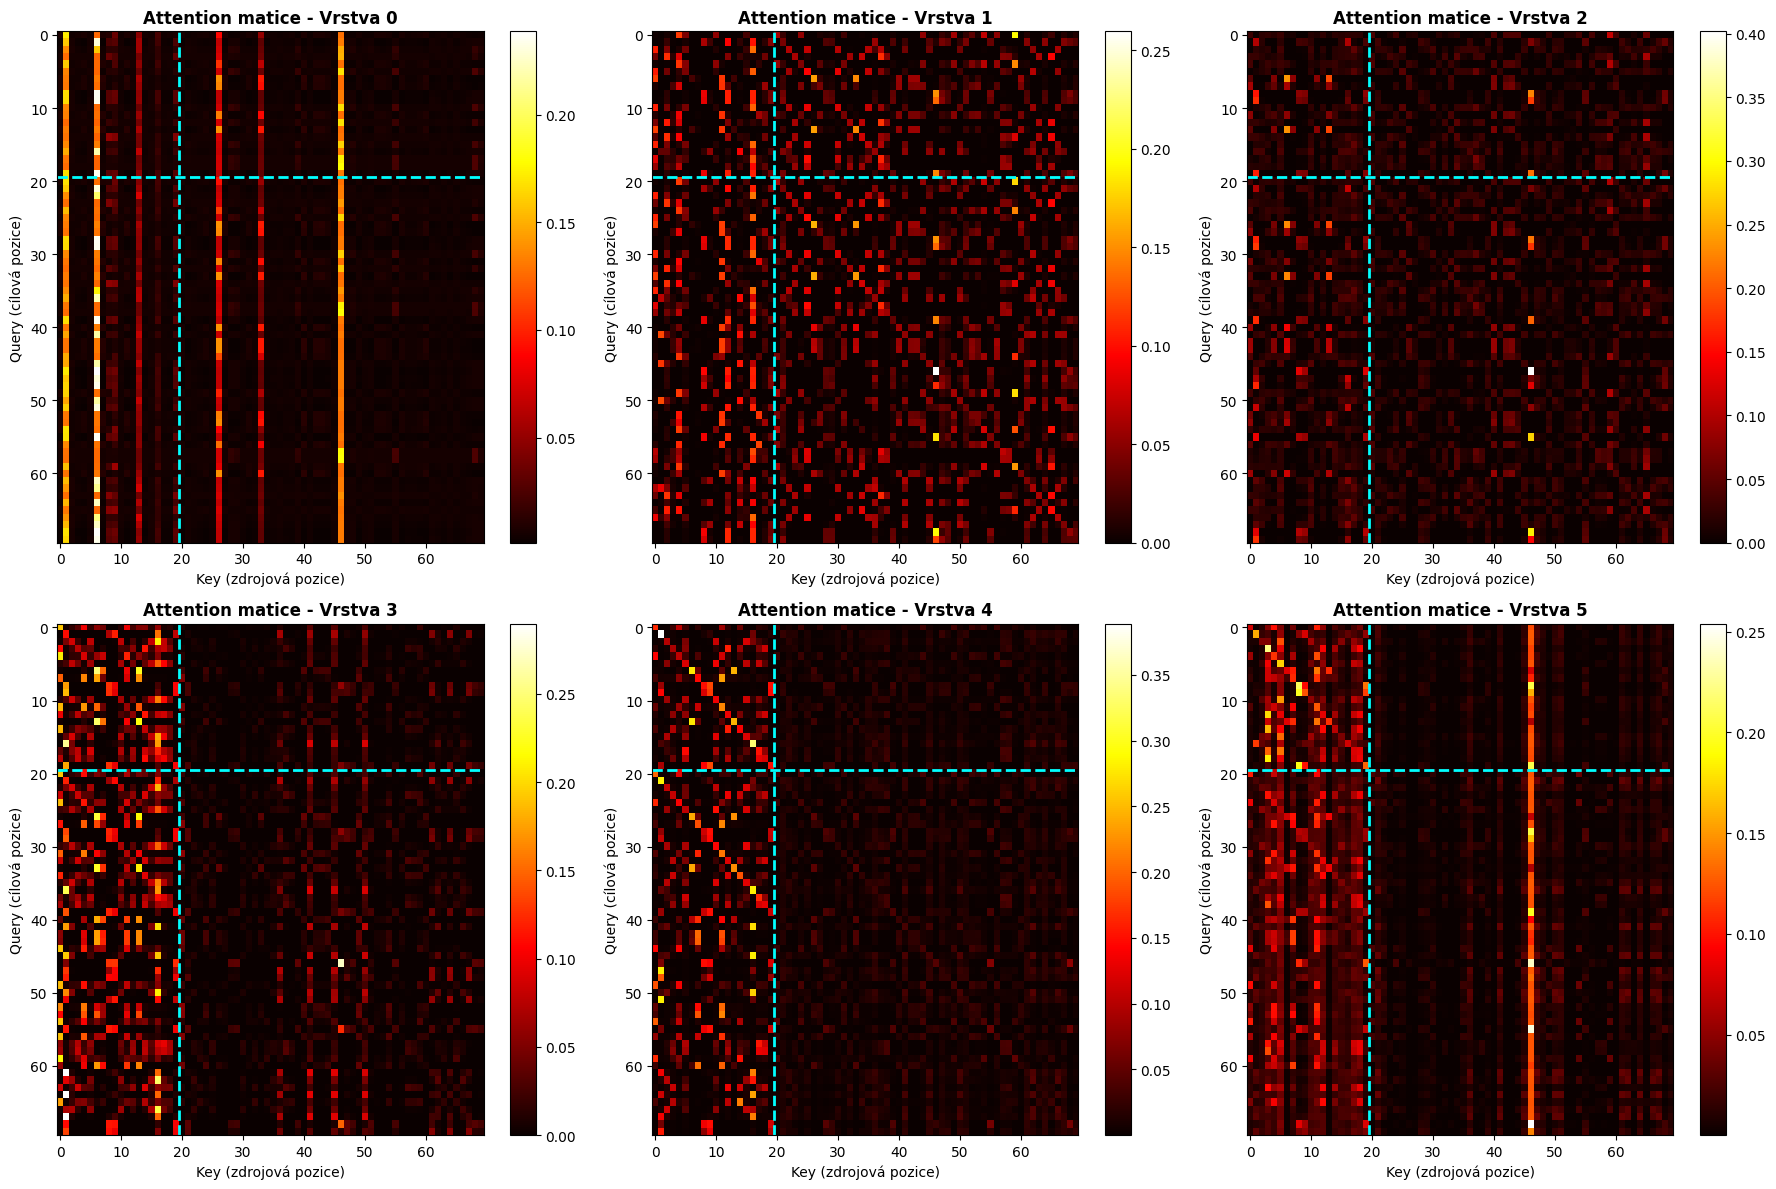

In [36]:
# =============================================
# EXPERIMENT 2: Zkoumání Attention vah
# =============================================

def compute_attention_weights(model, train_x, train_y, test_x):
    model.eval()
    layer_inputs = []
    def input_hook(module, inputs, output):
        layer_inputs.append(inputs[0].detach().cpu())
    hooks = []
    attn_modules = []
    for name, module in model.named_modules():
        if 'self_attn_between_items' in name and 'self_attn_between_items.' not in name:
            hooks.append(module.register_forward_hook(input_hook))
            attn_modules.append(module)
    with torch.no_grad():
        _ = model(train_x[None], train_y[None], test_x[None])
    for hook in hooks:
        hook.remove()
    all_attention_weights = []
    for layer_idx, module in enumerate(attn_modules):
        if layer_idx >= len(layer_inputs):
            break
        x = layer_inputs[layer_idx]
        w_qkv = module.w_qkv.cpu()
        batch, features, seq_len_attn, embed_dim = x.shape
        n_heads = w_qkv.shape[1]
        head_dim = w_qkv.shape[2]
        x_flat = x.reshape(-1, embed_dim)
        W_q = w_qkv[0]; W_k = w_qkv[1]
        W_q_t = W_q.permute(2, 0, 1); W_k_t = W_k.permute(2, 0, 1)
        Q = torch.matmul(x_flat, W_q_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)
        K = torch.matmul(x_flat, W_k_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)
        Q = Q.reshape(batch, features, seq_len_attn, n_heads, head_dim).permute(0, 1, 3, 2, 4)
        K = K.reshape(batch, features, seq_len_attn, n_heads, head_dim).permute(0, 1, 3, 2, 4)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (head_dim ** 0.5)
        attn_w = F.softmax(scores, dim=-1)
        all_attention_weights.append(attn_w)
    return all_attention_weights, layer_inputs

# Použije globální train_x, train_y, test_x z buňky DATASET
attn_weights, layer_inputs = compute_attention_weights(loaded_model, train_x, train_y, test_x)

print(f"Počet vrstev: {len(attn_weights)}")
for i, w in enumerate(attn_weights):
    print(f"Vrstva {i}: attention shape = {w.shape}")

fig1, axes1 = plt.subplots(2, 3, figsize=(18, 12))
axes1 = axes1.flatten()
for layer_idx in range(6):
    attn_layer = attn_weights[layer_idx][0, 0].mean(dim=0).detach().numpy()
    ax = axes1[layer_idx]
    im = ax.imshow(attn_layer, cmap='hot', aspect='auto')
    ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
    ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
    ax.set_xlabel('Key (zdrojová pozice)')
    ax.set_ylabel('Query (cílová pozice)')
    ax.set_title(f'Attention matice - Vrstva {layer_idx}', fontweight='bold')
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# Interpretace Experimentu 2

* Struktura attention matic přes vrstvy.
* Hledáme asymetrii: Test→Train aktivní, Train→Test nulový.

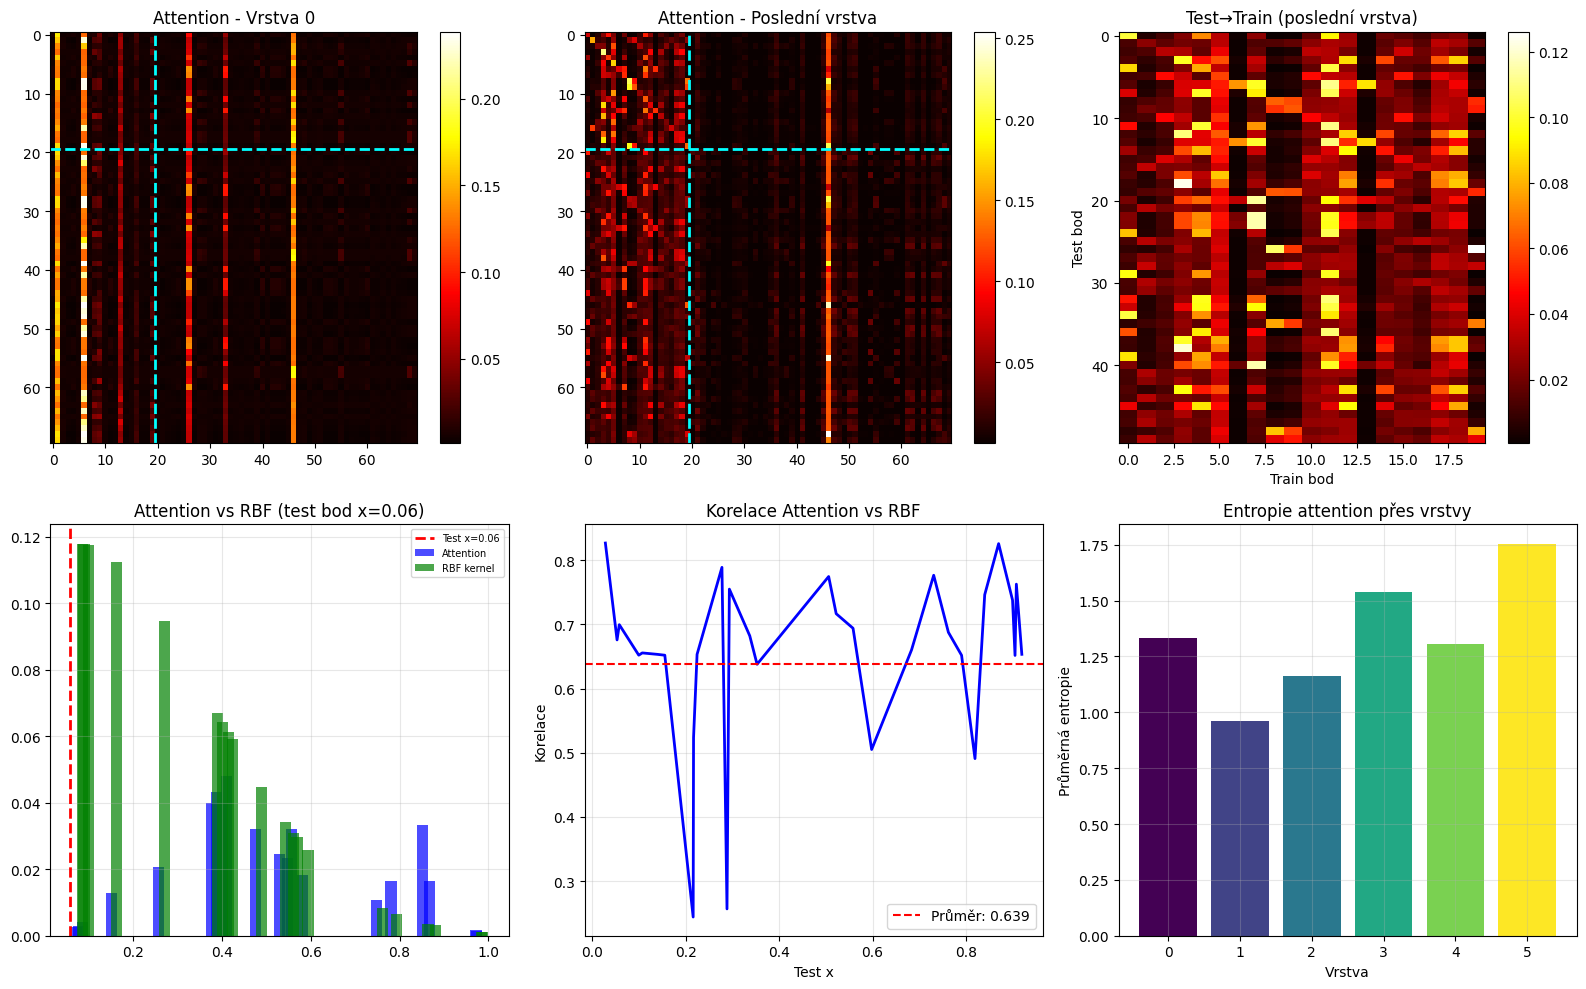

Průměrná korelace Attention vs RBF: 0.6388


In [37]:
# =============================================
# EXPERIMENT 3: Detailní attention analýza + RBF porovnání
# =============================================
# Používá attn_weights z předchozí buňky

attn_layer0 = attn_weights[0][0, 0].mean(dim=0).detach().numpy()
attn_layer5 = attn_weights[-1][0, 0].mean(dim=0).detach().numpy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ax = axes[0, 0]
im = ax.imshow(attn_layer0, cmap='hot', aspect='auto')
ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.set_title('Attention - Vrstva 0'); plt.colorbar(im, ax=ax)

ax = axes[0, 1]
im = ax.imshow(attn_layer5, cmap='hot', aspect='auto')
ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.set_title('Attention - Poslední vrstva'); plt.colorbar(im, ax=ax)

test_to_train_attn = attn_layer5[n_context:, :n_context]
ax = axes[0, 2]
im = ax.imshow(test_to_train_attn, cmap='hot', aspect='auto')
ax.set_xlabel('Train bod'); ax.set_ylabel('Test bod')
ax.set_title('Test→Train (poslední vrstva)'); plt.colorbar(im, ax=ax)

test_idx = min(15, test_to_train_attn.shape[0] - 1)
test_x_val = test_x[n_context + test_idx, 0].cpu().item()
attn_to_train = attn_layer5[n_context + test_idx, :n_context]
train_x_np = train_x[:, 0].cpu().numpy()
rbf_w = np.exp(-0.5 * (train_x_np - test_x_val)**2 / hps['lengthscale']**2)
rbf_w_norm = rbf_w / rbf_w.sum()
order = np.argsort(train_x_np)

ax = axes[1, 0]
ax.bar(train_x_np[order], attn_to_train[order], width=0.025, alpha=0.7, label='Attention', color='blue')
ax.bar(train_x_np[order]+0.013, rbf_w_norm[order], width=0.025, alpha=0.7, label='RBF kernel', color='green')
ax.axvline(x=test_x_val, color='red', linestyle='--', lw=2, label=f'Test x={test_x_val:.2f}')
ax.set_title(f'Attention vs RBF (test bod x={test_x_val:.2f})'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

correlations = []
for i in range(test_to_train_attn.shape[0]):
    txv = test_x[i, 0].cpu().item() 
    a2t = test_to_train_attn[i]        
    rw = np.exp(-0.5 * (train_x_np - txv)**2 / hps['lengthscale']**2)
    rw = rw / rw.sum()
    c = np.corrcoef(a2t, rw)[0, 1]
    correlations.append(c if not np.isnan(c) else 0.0)

test_x_test = test_x[n_context:, 0].cpu().numpy()
srt = test_x_test.argsort()
ax = axes[1, 1]
ax.plot(test_x_test[srt], np.array(correlations)[srt], 'b-', lw=2)
ax.axhline(y=np.mean(correlations), color='red', linestyle='--', label=f'Průměr: {np.mean(correlations):.3f}')
ax.set_xlabel('Test x'); ax.set_ylabel('Korelace')
ax.set_title('Korelace Attention vs RBF'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
for li in range(min(6, len(attn_weights))):
    al = attn_weights[li][0, 0].mean(dim=0).detach().numpy()
    t2t = al[n_context:, :n_context]
    entropy = -np.sum(t2t * np.log(t2t + 1e-10), axis=1).mean()
    ax.bar(li, entropy, color=plt.cm.viridis(li/5))
ax.set_xlabel('Vrstva'); ax.set_ylabel('Průměrná entropie')
ax.set_title('Entropie attention přes vrstvy'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Průměrná korelace Attention vs RBF: {np.mean(correlations):.4f}")

Ktera casr attention je zodpovedna za co, co odpovida bodum a co odpovida hyperparametru 
co se stano pro pfn s jednou vrstvou

# Interpretace Experimentu 3

* Attention vs RBF kernel: podobný trend, ale attention je ostřejší.
* Entropie přes vrstvy ukazuje, jak se mění šířka attention.

n_context= 5: MSE PFN=0.0767±0.1348  MSE GP=0.0650±0.1121
n_context=10: MSE PFN=0.0188±0.0625  MSE GP=0.0030±0.0017
n_context=15: MSE PFN=0.0131±0.0314  MSE GP=0.0033±0.0038
n_context=20: MSE PFN=0.0261±0.0700  MSE GP=0.0022±0.0018


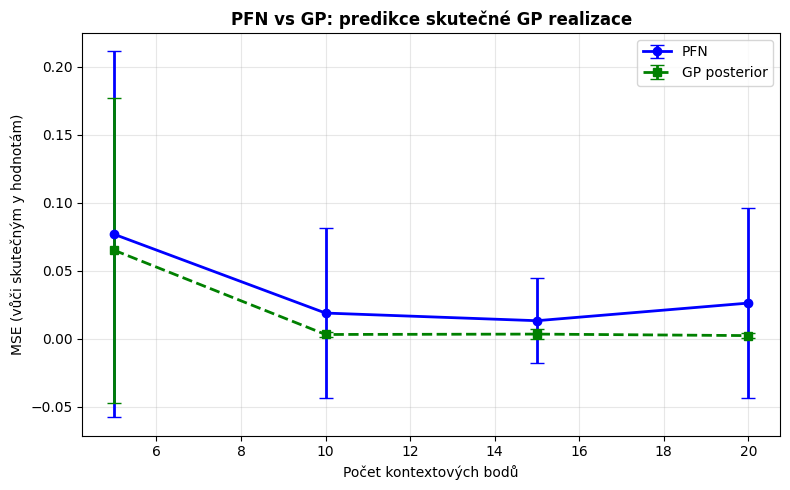

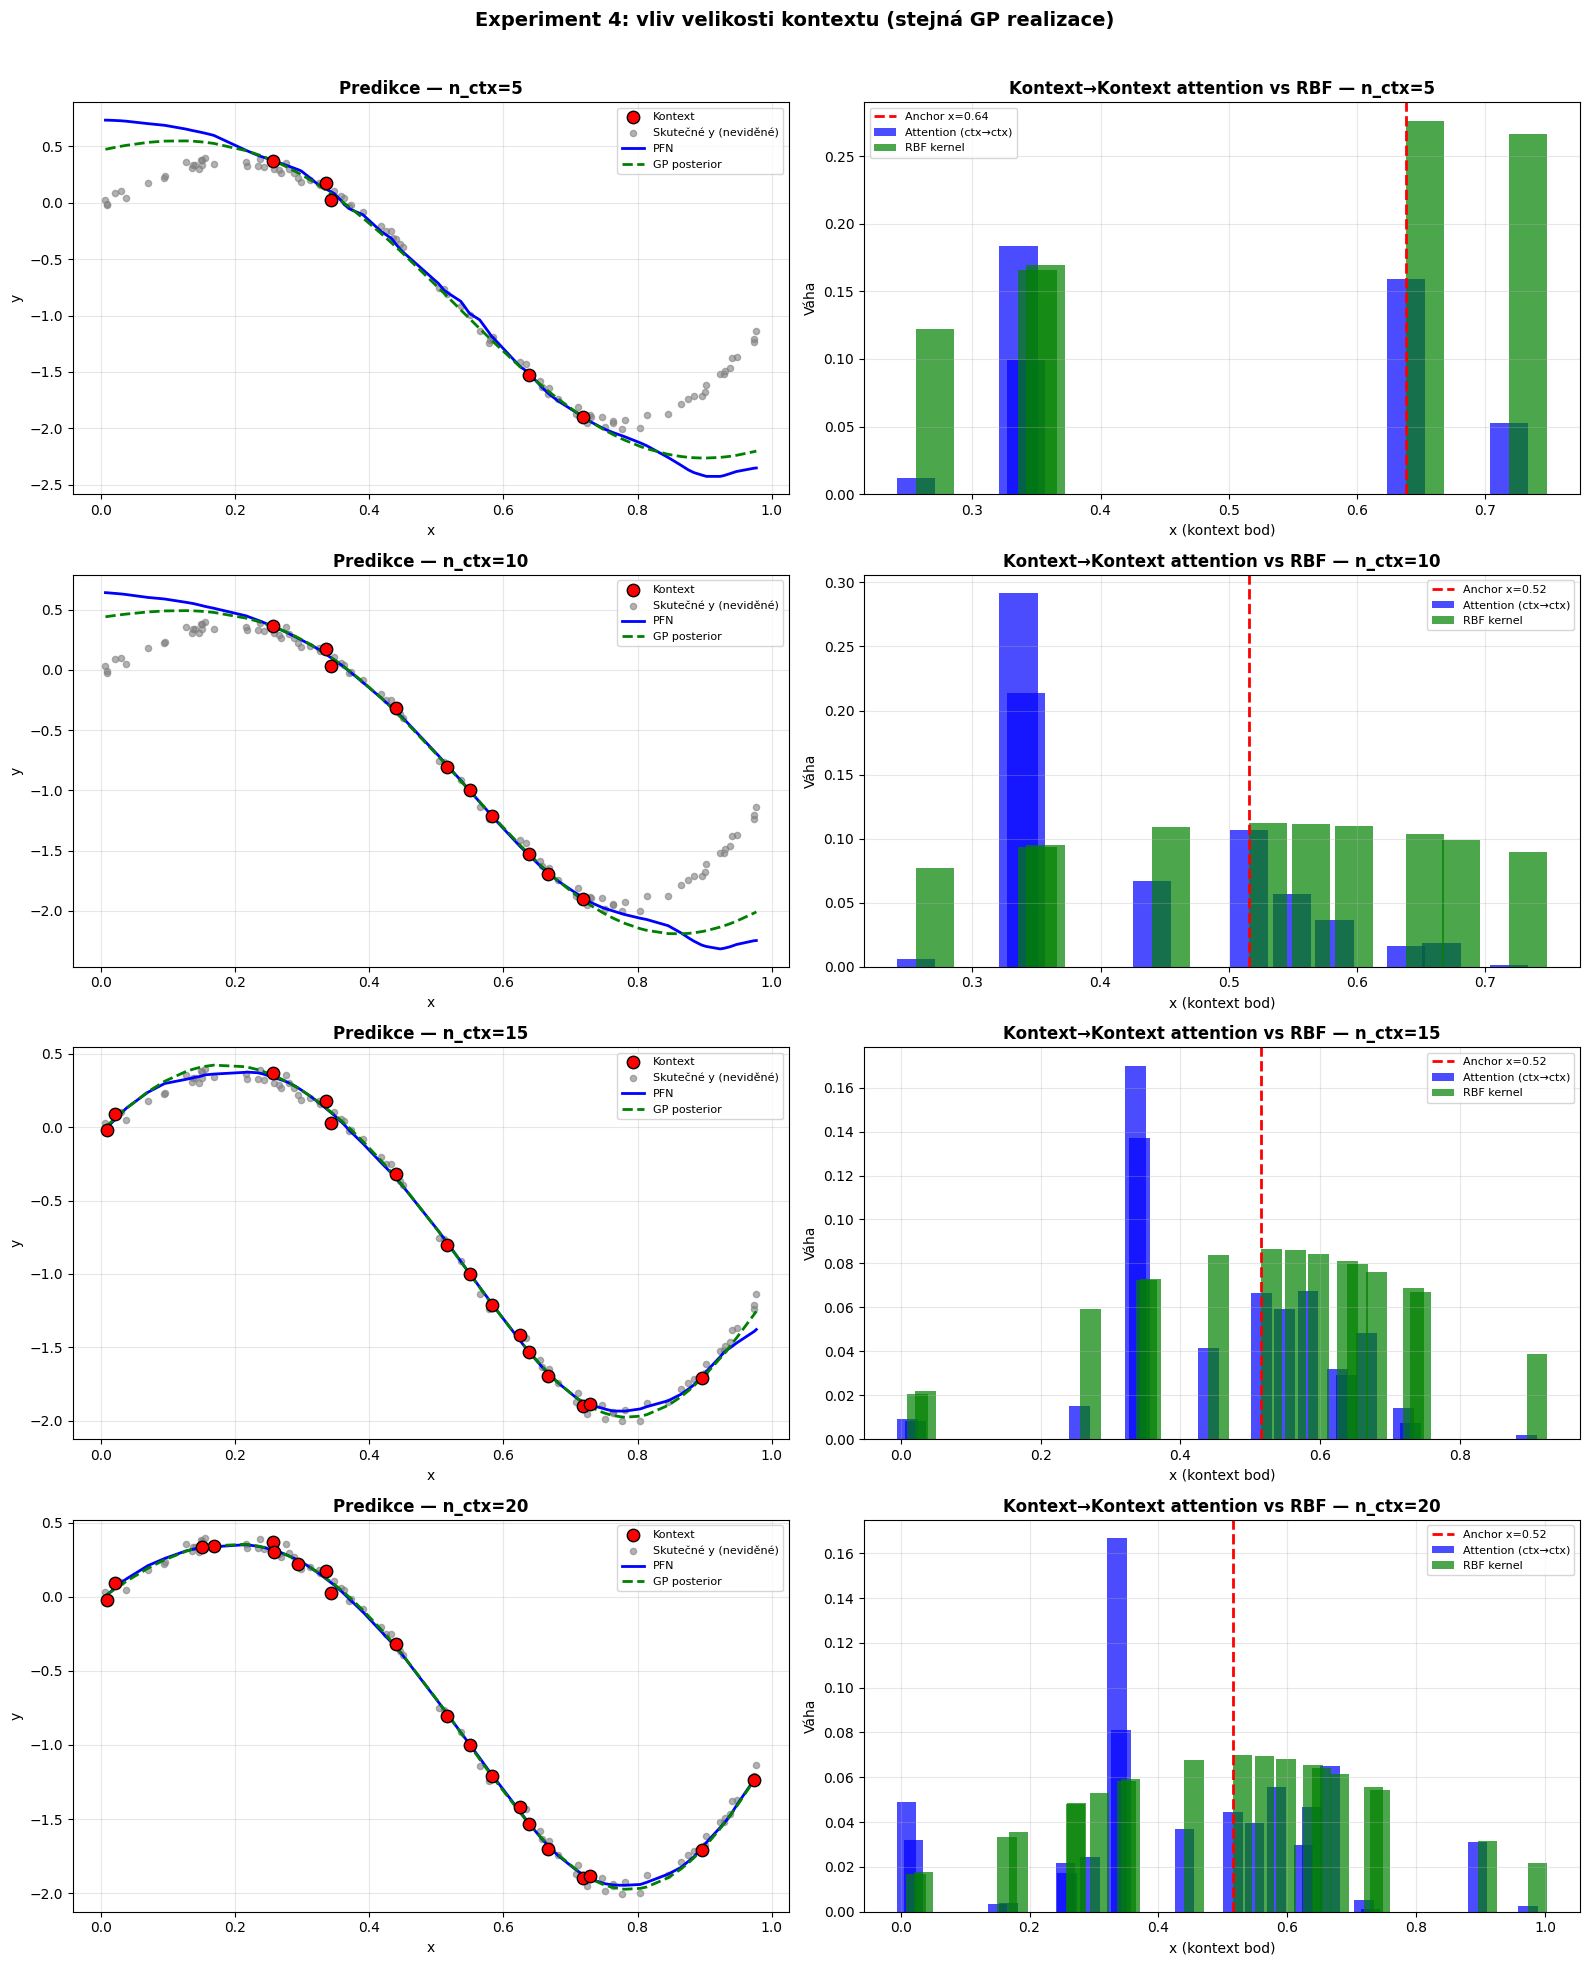

In [38]:
# =============================================
# EXPERIMENT 4: PFN vs GP s omezeným kontextem
# =============================================
# Jak dobře PFN aproximuje skutečné GP hodnoty,
# když vidí jen omezený počet bodů?

N_CONTEXT_LIST = [5, 10, 15, 20]
N_TOTAL = 100

def experiment_partial_observation(model, hps, n_total=N_TOTAL, n_context_list=N_CONTEXT_LIST):
    reset_seed()
    results = []
    for n_ctx in n_context_list:
        mses_pfn, mses_gp = [], []
        for _ in range(20):
            batch = get_batch_cpu(batch_size=1, seq_len=n_total, num_features=1, hyperparameters=hps, device=device)
            all_x = batch.x[0]; all_y = batch.y[0]
            idx = torch.randperm(n_total)
            train_x = all_x[idx[:n_ctx]]; train_y = all_y[idx[:n_ctx]]
            test_x = all_x[idx[n_ctx:]]; true_y = all_y[idx[n_ctx:]]

            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

            kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
            gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
            gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred = gp.predict(test_x.cpu().numpy())

            true_y_np = true_y.cpu().numpy()
            mses_pfn.append(np.mean((pfn_pred - true_y_np)**2))
            mses_gp.append(np.mean((gp_pred - true_y_np)**2))

        results.append({
            'n_context': n_ctx,
            'mse_pfn_mean': np.mean(mses_pfn), 'mse_pfn_std': np.std(mses_pfn),
            'mse_gp_mean': np.mean(mses_gp), 'mse_gp_std': np.std(mses_gp),
        })
        print(f"n_context={n_ctx:2d}: MSE PFN={np.mean(mses_pfn):.4f}±{np.std(mses_pfn):.4f}  "
              f"MSE GP={np.mean(mses_gp):.4f}±{np.std(mses_gp):.4f}")
    return results

results_partial = experiment_partial_observation(loaded_model, hps)

fig, ax = plt.subplots(figsize=(8, 5))
n_ctx_vals = [r['n_context'] for r in results_partial]
ax.errorbar(n_ctx_vals, [r['mse_pfn_mean'] for r in results_partial],
            yerr=[r['mse_pfn_std'] for r in results_partial],
            marker='o', capsize=5, lw=2, label='PFN', color='blue')
ax.errorbar(n_ctx_vals, [r['mse_gp_mean'] for r in results_partial],
            yerr=[r['mse_gp_std'] for r in results_partial],
            marker='s', capsize=5, lw=2, label='GP posterior', color='green', linestyle='--')
ax.set_xlabel('Počet kontextových bodů')
ax.set_ylabel('MSE (vůči skutečným y hodnotám)')
ax.set_title('PFN vs GP: predikce skutečné GP realizace', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- Jeden řádek grafů pro každý n_ctx ---
# Sdílená realizace GP pro všechny kontexty (stejná data, různě velký kontext)
batch_vis = get_batch_for_gp(batch_size=1, seq_len=N_TOTAL, num_features=1, hyperparameters=hps_demo)
all_x_vis = batch_vis.x[0]; all_y_vis = batch_vis.y[0]
perm      = torch.randperm(N_TOTAL)   # stejná permutace pro všechny n_ctx

fig, axes = plt.subplots(len(N_CONTEXT_LIST), 2, figsize=(16, 5 * len(N_CONTEXT_LIST)))

for row, n_ctx in enumerate(N_CONTEXT_LIST):
    ctx_idx  = perm[:n_ctx];  test_idx_vis = perm[n_ctx:]
    train_x  = all_x_vis[ctx_idx];   train_y  = all_y_vis[ctx_idx]
    test_x   = all_x_vis[test_idx_vis]; true_y = all_y_vis[test_idx_vis]

    # PFN predikce
    with torch.no_grad():
        logits = loaded_model(train_x[None], train_y[None], test_x[None])
    pfn_pred = loaded_model.criterion.mean(logits)[0].cpu().numpy()

    # GP predikce
    kernel = ConstantKernel(hps_demo['outputscale']) * RBF(length_scale=hps_demo['lengthscale'])
    gp     = GaussianProcessRegressor(kernel=kernel, alpha=hps_demo['noise'])
    gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
    gp_pred = gp.predict(test_x.cpu().numpy())

    t_order = test_x[:, 0].cpu().argsort()

    # ── levý sloupec: predikce ──
    ax_pred = axes[row, 0]
    ax_pred.scatter(train_x[:, 0].cpu(), train_y.cpu(),
                    c='red', s=80, zorder=10, label='Kontext', edgecolors='black')
    ax_pred.scatter(test_x[t_order, 0].cpu(), true_y.cpu()[t_order],
                    c='gray', s=20, alpha=0.6, label='Skutečné y (neviděné)')
    ax_pred.plot(test_x[t_order, 0].cpu(), pfn_pred[t_order], 'b-',  lw=2, label='PFN')
    ax_pred.plot(test_x[t_order, 0].cpu(), gp_pred[t_order],  'g--', lw=2, label='GP posterior')
    ax_pred.set_title(f'Predikce — n_ctx={n_ctx}', fontweight='bold')
    ax_pred.set_xlabel('x'); ax_pred.set_ylabel('y')
    ax_pred.legend(fontsize=8); ax_pred.grid(True, alpha=0.3)

    # ── pravý sloupec: attention kontext→kontext vs RBF ──
    all_seq_x = torch.cat([train_x, test_x], dim=0)
    attn_w, _ = compute_attention_weights(loaded_model, train_x, train_y, all_seq_x)
    attn_layer5 = attn_w[5][0, 0].mean(dim=0).detach().numpy()

    train_x_np  = train_x[:, 0].cpu().numpy()
    order       = np.argsort(train_x_np)
    # Vyber kontext bod nejblíže x=0.5
    ctx_pick    = int(np.argmin(np.abs(train_x_np - 0.5)))
    anchor_x    = train_x_np[ctx_pick]

    # Attention tohoto kontext bodu na VŠECHNY ostatní kontext body
    attn_ctx2ctx = attn_layer5[ctx_pick, :n_ctx]   # řádek ctx_pick, sloupce 0..n_ctx

    # RBF kernel: k(anchor, x_j) normalizovaný
    rbf_raw  = np.exp(-0.5 * (train_x_np - anchor_x)**2 / hps_demo['lengthscale']**2)
    rbf_norm = rbf_raw / rbf_raw.sum()

    ax_attn = axes[row, 1]
    ax_attn.bar(train_x_np[order],         attn_ctx2ctx[order], width=0.03,
                alpha=0.7, label='Attention (ctx→ctx)', color='blue')
    ax_attn.bar(train_x_np[order] + 0.015, rbf_norm[order],     width=0.03,
                alpha=0.7, label='RBF kernel', color='green')
    ax_attn.axvline(x=anchor_x, color='red', linestyle='--', lw=2,
                    label=f'Anchor x={anchor_x:.2f}')
    ax_attn.set_title(f'Kontext→Kontext attention vs RBF — n_ctx={n_ctx}', fontweight='bold')
    ax_attn.set_xlabel('x (kontext bod)'); ax_attn.set_ylabel('Váha')
    ax_attn.legend(fontsize=8); ax_attn.grid(True, alpha=0.3)

plt.suptitle('Experiment 4: vliv velikosti kontextu (stejná GP realizace)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

* Pro menší kontext je MSE mezi reálným modelem a PFN vždy nižší než pro GP, ale ta situace se rychle mění, jakmile se zvětší počet kontext bodů, v tomto případě PFN prohrává.
* Současně je vidět, že skrytím kontext bodů nutíme attention dávat pozor i na mnohem vzdálenější body od referenčního bodu. Ale pořad attention není tak rovnoměrné jako RBF.
* PFN trénovaný na distribuci HP pravděpodobně dělá implicitní marginalizaci — průměruje predikce přes různé možné HP.
*  S 5 body je lengthscale špatně identifikovatelný, takže GP s fixním může být horší, než průměr přes více možných hodnot tohoto hyperparametru. Marginalizace je teoreticky optimální strategie při nejistotě o HP, (ukazují v Müller et al.  v Figure 4b.)
* Pro n_context=10+ už GP vyhrává, protože s dostatkem dat je fixní správný HP lepší než marginalizace.

LS=0.05: MEDIAN=0.020331, MEAN=0.034554 ± 0.039644, outliers=0/15
LS=0.10: MEDIAN=0.000629, MEAN=0.001048 ± 0.001193, outliers=2/15
LS=0.20: MEDIAN=0.000146, MEAN=0.000217 ± 0.000272, outliers=1/15
LS=0.30: MEDIAN=0.000048, MEAN=0.000121 ± 0.000166, outliers=2/15
LS=0.50: MEDIAN=0.000035, MEAN=0.000047 ± 0.000033, outliers=0/15
LS=0.70: MEDIAN=0.000047, MEAN=0.000054 ± 0.000032, outliers=0/15
LS=0.90: MEDIAN=0.000033, MEAN=0.000045 ± 0.000034, outliers=0/15


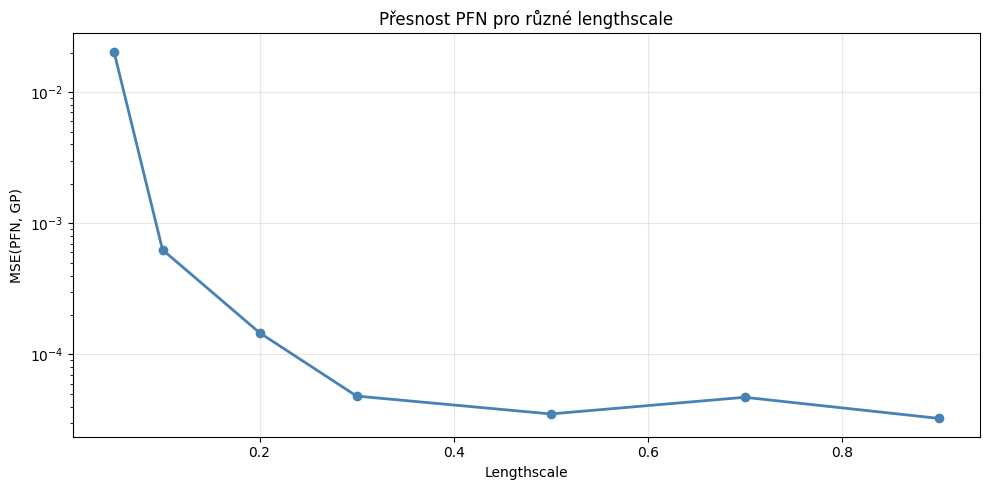

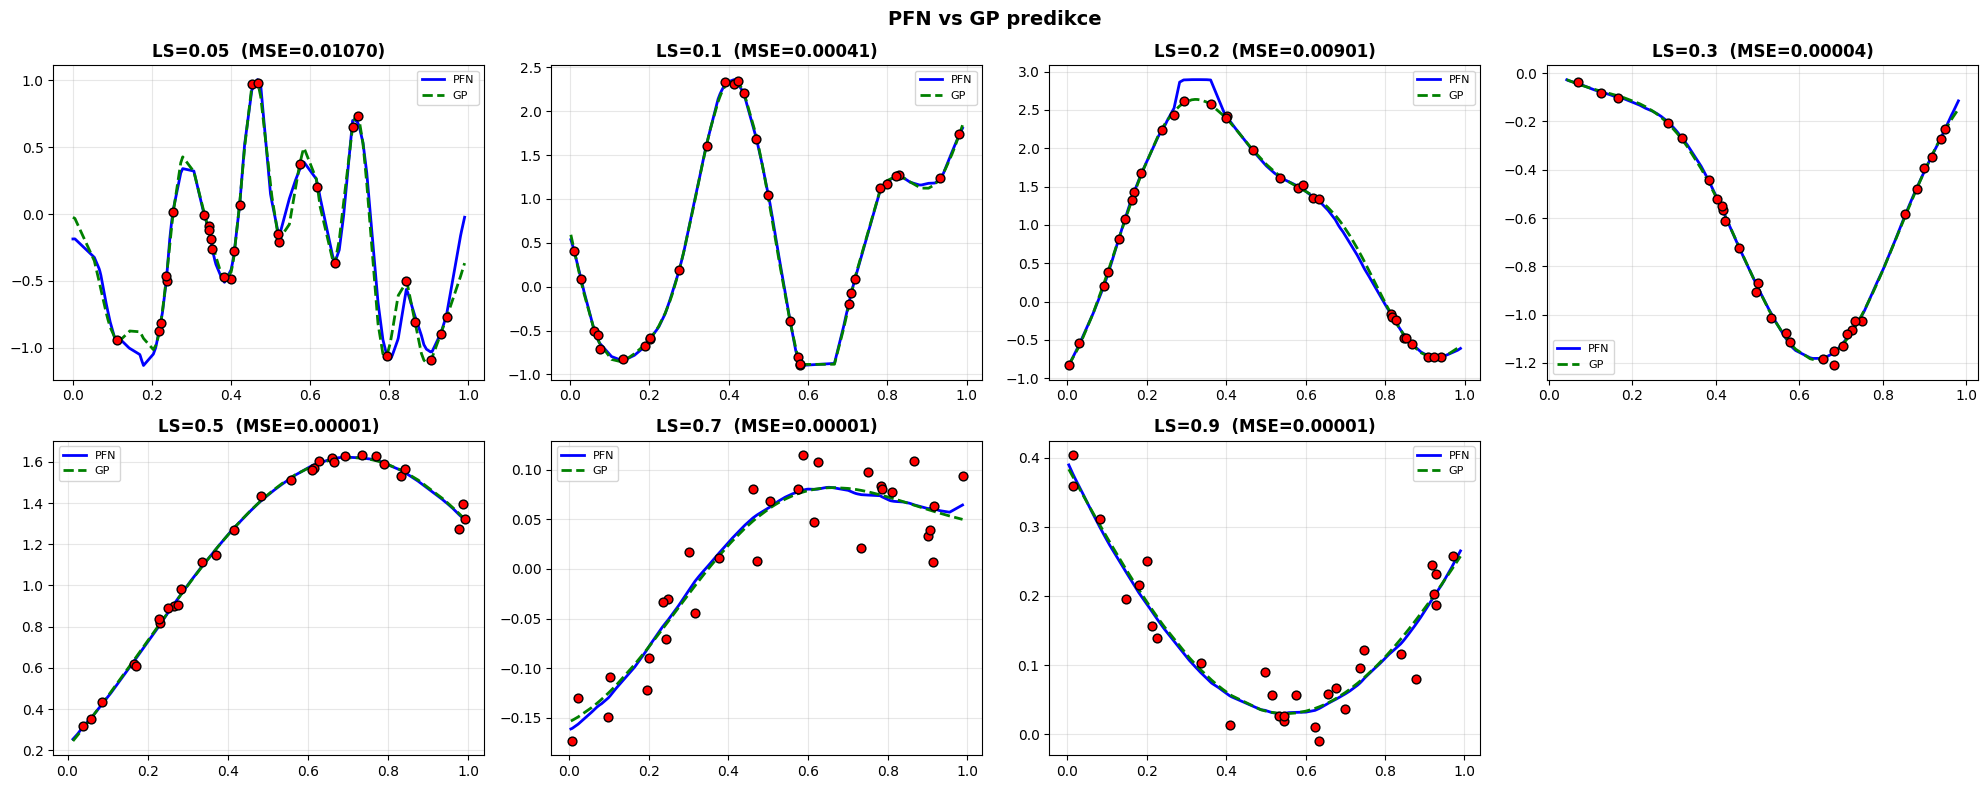

In [39]:
# =============================================
# EXPERIMENT 5: Přesnost PFN pro různé lengthscale
# =============================================
# Jednoduché MSE(PFN, GP) přes LS — ukazuje,
# pro které LS model funguje dobře a pro které ne.

def test_pfn_accuracy_across_ls(model,
                                 test_lengthscales=[0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9],
                                 n_context=30, seq_len=100, n_trials=15):
    reset_seed()
    results = []

    for ls in test_lengthscales:
        hps_test = {"noise": 1e-3, "outputscale": 1.0, "lengthscale": ls}
        mse_list = []

        for _ in range(n_trials):
            
            batch = get_batch_cpu(batch_size=1, seq_len=seq_len, num_features=1,
                                      hyperparameters=hps_test, device=device)
            train_x = batch.x[0, :n_context]
            train_y = batch.y[0, :n_context]
            test_x = batch.x[0]

            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

            kernel = ConstantKernel(1.0) * RBF(length_scale=ls)
            gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-3)
            gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred = gp.predict(test_x.cpu().numpy())

            mse_list.append(np.mean((pfn_pred - gp_pred)**2))

        mse_arr = np.array(mse_list)
        median = np.median(mse_arr)
        mask = mse_arr < max(median * 10, 0.01)
        mse_filtered = mse_arr[mask]

        results.append({
            'lengthscale': ls,
            'mse_mean': np.mean(mse_filtered),
            'mse_std': np.std(mse_filtered),
            'mse_median': np.median(mse_filtered),
            'n_outliers': int(np.sum(~mask)),
        })
        print(f"LS={ls:.2f}: MEDIAN={np.median(mse_filtered):.6f}, "
              f"MEAN={np.mean(mse_filtered):.6f} ± {np.std(mse_filtered):.6f}, "
              f"outliers={int(np.sum(~mask))}/{len(mse_list)}")


    # Graf 1: MSE přes LS
    fig, ax = plt.subplots(figsize=(10, 5))
    ls_vals = [r['lengthscale'] for r in results]
    ax.plot(ls_vals, [r['mse_median'] for r in results],
            marker='o', lw=2, color='steelblue')
    ax.set_ylabel('Median MSE(PFN, GP)')
    ax.set_xlabel('Lengthscale'); ax.set_ylabel('MSE(PFN, GP)')
    ax.set_title('Přesnost PFN pro různé lengthscale'); ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # Graf 2: Ukázky predikcí
    reset_seed()
    show_ls = test_lengthscales
    n_cols = 4
    n_rows = math.ceil(len(show_ls) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()
    for idx, ls in enumerate(show_ls):
        hps_test = {"noise": 1e-3, "outputscale": 1.0, "lengthscale": ls}
        batch = get_batch_cpu(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps_test, device=device)
        tx = batch.x[0, :n_context]; ty = batch.y[0, :n_context]; tex = batch.x[0]
        with torch.no_grad():
            logits = model(tx[None], ty[None], tex[None])
        pfn_p = model.criterion.mean(logits)[0].cpu().numpy()
        kernel = ConstantKernel(1.0) * RBF(length_scale=ls)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-3)
        gp.fit(tx.cpu().numpy(), ty.cpu().numpy())
        gp_p = gp.predict(tex.cpu().numpy())
        o = tex[:, 0].cpu().argsort()
        ax = axes[idx]
        ax.scatter(tx[:, 0].cpu(), ty.cpu(), c='red', s=40, zorder=10, edgecolors='black')
        ax.plot(tex[o, 0].cpu(), pfn_p[o], 'b-', lw=2, label='PFN')
        ax.plot(tex[o, 0].cpu(), gp_p[o], 'g--', lw=2, label='GP')
        mse = np.mean((pfn_p - gp_p)**2)
        ax.set_title(f'LS={ls}  (MSE={mse:.5f})', fontweight='bold')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    # Skryj prázdné subploty
    for idx in range(len(show_ls), len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle('PFN vs GP predikce', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

results_4 = test_pfn_accuracy_across_ls(loaded_model)

* Zde jsme zkoušeli, jak moc dobře umí PFN odhadnout správný lengthscale.
* Je vidět, že čím divočejší je ta funkce, tím hůř PFN odhaduje lengthscale, nepomáhá ani přidání množství kontext bodů.

---
# NOVÉ EXPERIMENTY: Identifikace hyperparametrů
---

EXPERIMENT 6: Kolik context bodů potřebuje na identifikaci HP?

--- Test s krátkým lengthscale (0.1) ---
n_ctx=  3: MSE(correct)=0.296494, MSE(wrong)=0.622308
n_ctx=  5: MSE(correct)=0.147087, MSE(wrong)=0.495897
n_ctx= 10: MSE(correct)=0.056607, MSE(wrong)=0.769824
n_ctx= 20: MSE(correct)=0.003692, MSE(wrong)=0.671712
n_ctx= 40: MSE(correct)=0.011819, MSE(wrong)=0.676424
n_ctx= 60: MSE(correct)=0.005589, MSE(wrong)=0.150935


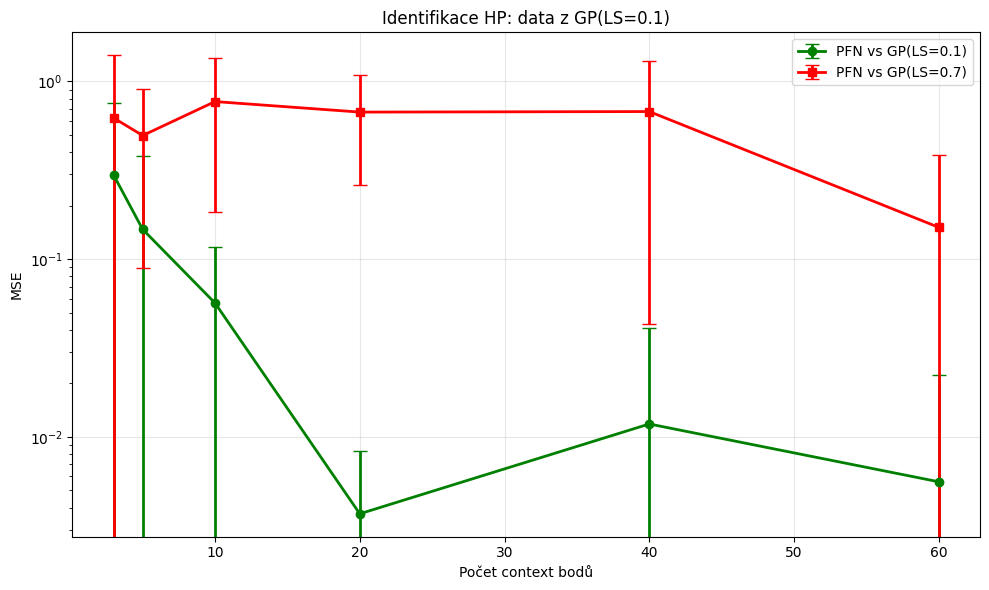


--- Test s dlouhým lengthscale (0.2) ---
n_ctx=  3: MSE(correct)=0.081058, MSE(wrong)=0.315508
n_ctx=  5: MSE(correct)=0.080859, MSE(wrong)=0.664603
n_ctx= 10: MSE(correct)=0.003524, MSE(wrong)=0.703921
n_ctx= 20: MSE(correct)=0.001459, MSE(wrong)=0.531505
n_ctx= 40: MSE(correct)=0.001273, MSE(wrong)=0.237685
n_ctx= 60: MSE(correct)=0.000554, MSE(wrong)=0.094314


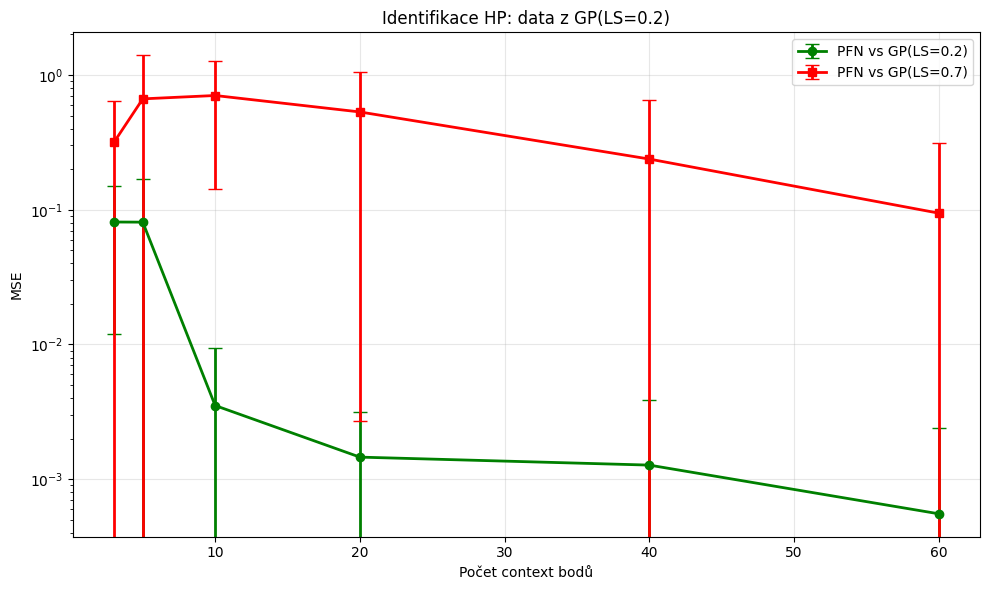

In [40]:
# =============================================
# EXPERIMENT 6: Kolik context bodů potřebuje na identifikaci HP?
# =============================================

def test_context_size_for_hp_identification(model, test_lengthscale=0.1,
                                             context_sizes=[3, 5, 10, 20, 40, 60],
                                             n_trials=15):
    reset_seed()
    hps_test = {"noise": 1e-3, "outputscale": 1.0, "lengthscale": test_lengthscale}
    results = []
    for n_ctx in context_sizes:
        mse_correct_list, mse_wrong_list = [], []
        for _ in range(n_trials):
            batch = get_batch_cpu(batch_size=1, seq_len=max(100, n_ctx+30), num_features=1,
                                      hyperparameters=hps_test, device=device)
            train_x = batch.x[0, :n_ctx]; train_y = batch.y[0, :n_ctx]; test_x = batch.x[0]
            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()
            kernel_c = ConstantKernel(1.0) * RBF(length_scale=test_lengthscale)
            gp_c = GaussianProcessRegressor(kernel=kernel_c, alpha=1e-3)
            gp_c.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred_c = gp_c.predict(test_x.cpu().numpy())
            wrong_ls = 0.7 if test_lengthscale < 0.3 else 0.05
            kernel_w = ConstantKernel(1.0) * RBF(length_scale=wrong_ls)
            gp_w = GaussianProcessRegressor(kernel=kernel_w, alpha=1e-3)
            gp_w.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred_w = gp_w.predict(test_x.cpu().numpy())
            mse_correct_list.append(np.mean((pfn_pred - gp_pred_c)**2))
            mse_wrong_list.append(np.mean((pfn_pred - gp_pred_w)**2))
        results.append({'n_context': n_ctx,
                        'mse_correct': np.mean(mse_correct_list), 'mse_correct_std': np.std(mse_correct_list),
                        'mse_wrong': np.mean(mse_wrong_list), 'mse_wrong_std': np.std(mse_wrong_list)})
        print(f"n_ctx={n_ctx:3d}: MSE(correct)={np.mean(mse_correct_list):.6f}, MSE(wrong)={np.mean(mse_wrong_list):.6f}")
    fig, ax = plt.subplots(figsize=(10, 6))
    n_vals = [r['n_context'] for r in results]
    ax.errorbar(n_vals, [r['mse_correct'] for r in results], yerr=[r['mse_correct_std'] for r in results],
                marker='o', lw=2, capsize=5, label=f'PFN vs GP(LS={test_lengthscale})', color='green')
    wrong_ls = 0.7 if test_lengthscale < 0.3 else 0.05
    ax.errorbar(n_vals, [r['mse_wrong'] for r in results], yerr=[r['mse_wrong_std'] for r in results],
                marker='s', lw=2, capsize=5, label=f'PFN vs GP(LS={wrong_ls})', color='red')
    ax.set_xlabel('Počet context bodů'); ax.set_ylabel('MSE')
    ax.set_title(f'Identifikace HP: data z GP(LS={test_lengthscale})')
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale('log')
    plt.tight_layout(); plt.show()
    return results

print("=" * 60)
print("EXPERIMENT 6: Kolik context bodů potřebuje na identifikaci HP?")
print("=" * 60)
print("\n--- Test s krátkým lengthscale (0.1) ---")
results_5a = test_context_size_for_hp_identification(loaded_model, test_lengthscale=0.1)
print("\n--- Test s dlouhým lengthscale (0.2) ---")
results_5b = test_context_size_for_hp_identification(loaded_model, test_lengthscale=0.2)

Postup: Data jsou z GP(LS=0.1). PFN dostane 3, 5, 10, 20, 40, 60 bodů a predikuje. Pak porovnáme PFN predikci se dvěma GP:

Zelená (correct): GP(LS=0.1) — správný lengthscale
Červená (wrong): GP(LS=0.3) — špatný lengthscale (3× delší)

Pokud PFN identifikoval LS z dat, jeho predikce bude blíž zelené (nízké MSE) a daleko od červené (vysoké MSE). Pokud neidentifikoval, obě MSE budou podobné.

EXPERIMENT 7: PFN vs Type-II ML
HP: LS=0.1, noise=0.001
  PFN:   MSE=0.012459, time=18.2ms
  ML-II: MSE=0.001316, time=32.5ms
  Speedup: 1.8x
HP: LS=0.3, noise=0.001
  PFN:   MSE=0.000618, time=17.1ms
  ML-II: MSE=0.000006, time=29.2ms
  Speedup: 1.7x
HP: LS=0.7, noise=0.001
  PFN:   MSE=0.000260, time=16.6ms
  ML-II: MSE=0.000038, time=27.7ms
  Speedup: 1.7x
HP: LS=0.3, noise=0.01
  PFN:   MSE=0.001566, time=15.8ms
  ML-II: MSE=0.000438, time=28.6ms
  Speedup: 1.8x


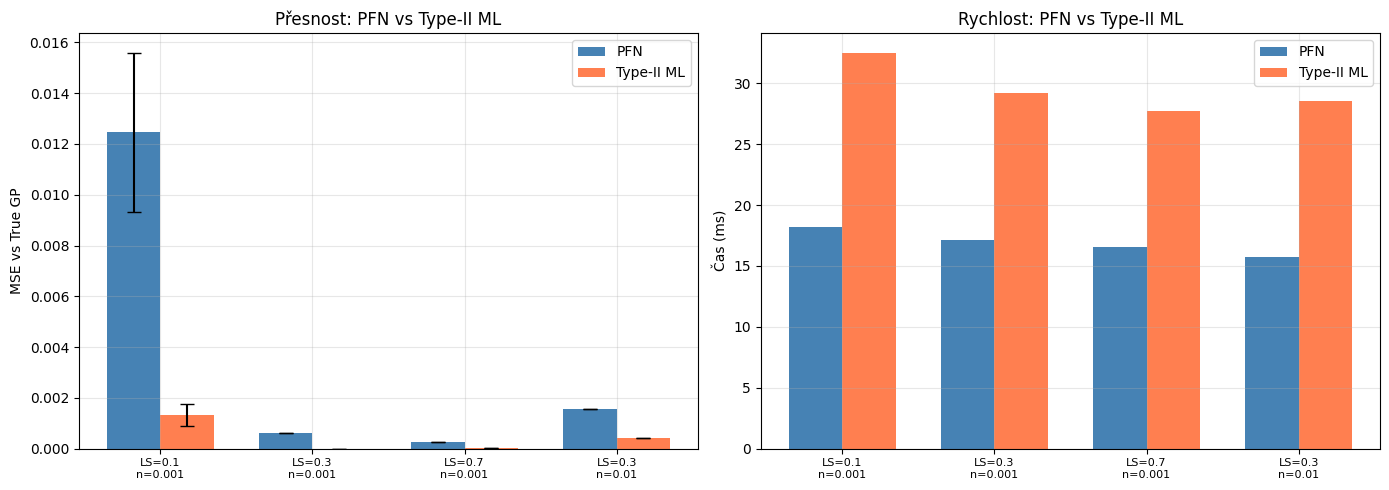

In [41]:
# =============================================
# EXPERIMENT 7: PFN vs Type-II ML
# =============================================

def type2_ml_predict(train_x_np, train_y_np, test_x_np):
    kernel = ConstantKernel(1.0, (0.01, 10.0)) * RBF(0.3, (0.01, 5.0)) + WhiteKernel(1e-3, (1e-6, 1e-1))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
    gp.fit(train_x_np, train_y_np)
    mean, std = gp.predict(test_x_np, return_std=True)
    return mean, std, gp.kernel_

def test_pfn_vs_type2ml(model, test_hps_list=None, n_context=20, n_trials=10):
    reset_seed()
    if test_hps_list is None:
        test_hps_list = [
            {"noise": 1e-3, "outputscale": 1.0, "lengthscale": 0.1},
            {"noise": 1e-3, "outputscale": 1.0, "lengthscale": 0.3},
            {"noise": 1e-3, "outputscale": 1.0, "lengthscale": 0.7},
            {"noise": 1e-2,  "outputscale": 0.5, "lengthscale": 0.3},
        ]
    all_results = []
    for hps_test in test_hps_list:
        ls = hps_test['lengthscale']
        mse_pfn_list, mse_ml2_list, time_pfn_list, time_ml2_list = [], [], [], []
        for trial in range(n_trials):
            batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps_test)
            train_x = batch.x[0, :n_context]; train_y = batch.y[0, :n_context]; test_x = batch.x[0]
            kernel_true = ConstantKernel(hps_test['outputscale']) * RBF(length_scale=ls)
            gp_true = GaussianProcessRegressor(kernel=kernel_true, alpha=hps_test['noise'], optimizer=None)
            gp_true.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred_true = gp_true.predict(test_x.cpu().numpy())
            t0 = time.time()
            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()
            time_pfn = time.time() - t0
            t0 = time.time()
            ml2_pred, _, _ = type2_ml_predict(train_x.cpu().numpy(), train_y.cpu().numpy(), test_x.cpu().numpy())
            time_ml2 = time.time() - t0
            mse_pfn_list.append(np.mean((pfn_pred - gp_pred_true)**2))
            mse_ml2_list.append(np.mean((ml2_pred - gp_pred_true)**2))
            time_pfn_list.append(time_pfn); time_ml2_list.append(time_ml2)
        result = {'hps': hps_test,
                  'mse_pfn': np.mean(mse_pfn_list), 'mse_pfn_std': np.std(mse_pfn_list),
                  'mse_ml2': np.mean(mse_ml2_list), 'mse_ml2_std': np.std(mse_ml2_list),
                  'time_pfn': np.mean(time_pfn_list), 'time_ml2': np.mean(time_ml2_list)}
        all_results.append(result)
        print(f"HP: LS={ls}, noise={hps_test['noise']}")
        print(f"  PFN:   MSE={result['mse_pfn']:.6f}, time={result['time_pfn']*1000:.1f}ms")
        print(f"  ML-II: MSE={result['mse_ml2']:.6f}, time={result['time_ml2']*1000:.1f}ms")
        print(f"  Speedup: {result['time_ml2']/max(result['time_pfn'], 1e-6):.1f}x")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    labels = [f"LS={r['hps']['lengthscale']}\nn={r['hps']['noise']}" for r in all_results]
    x_pos = np.arange(len(labels)); width = 0.35
    axes[0].bar(x_pos-width/2, [r['mse_pfn'] for r in all_results], width,
                yerr=[r['mse_pfn_std'] for r in all_results], label='PFN', color='steelblue', capsize=5)
    axes[0].bar(x_pos+width/2, [r['mse_ml2'] for r in all_results], width,
                yerr=[r['mse_ml2_std'] for r in all_results], label='Type-II ML', color='coral', capsize=5)
    axes[0].set_xticks(x_pos); axes[0].set_xticklabels(labels, fontsize=8)
    axes[0].set_ylabel('MSE vs True GP'); axes[0].set_title('Přesnost: PFN vs Type-II ML')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].bar(x_pos-width/2, [r['time_pfn']*1000 for r in all_results], width, label='PFN', color='steelblue')
    axes[1].bar(x_pos+width/2, [r['time_ml2']*1000 for r in all_results], width, label='Type-II ML', color='coral')
    axes[1].set_xticks(x_pos); axes[1].set_xticklabels(labels, fontsize=8)
    axes[1].set_ylabel('Čas (ms)'); axes[1].set_title('Rychlost: PFN vs Type-II ML')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return all_results

print("=" * 60)
print("EXPERIMENT 7: PFN vs Type-II ML")
print("=" * 60)
results_6 = test_pfn_vs_type2ml(loaded_model)

EXPERIMENT 8: Ambiguita — marginalizace vs point estimate
n_ctx=  3: PFN=0.03916, ML-II=0.02307, Marg=0.02140
n_ctx=  5: PFN=0.00473, ML-II=0.02377, Marg=0.01674
n_ctx= 10: PFN=0.00201, ML-II=0.17294, Marg=0.00843
n_ctx= 20: PFN=0.00064, ML-II=0.23283, Marg=0.00247
n_ctx= 50: PFN=0.00205, ML-II=212.61974, Marg=0.00147


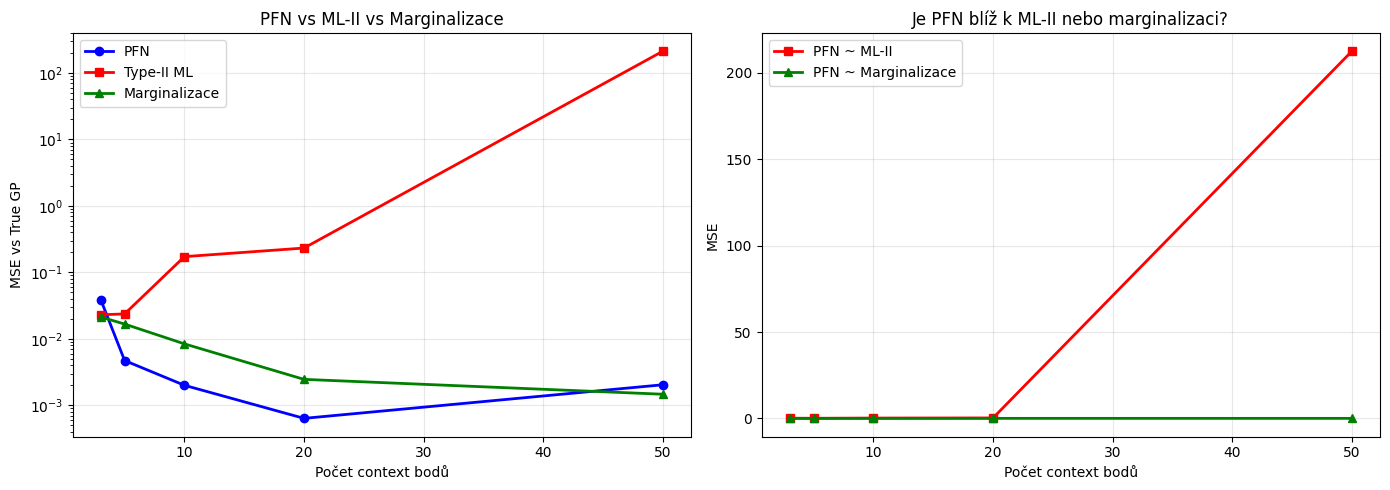

In [42]:
# =============================================
# EXPERIMENT 8: Ambiguita — marginalizace vs point estimate
# =============================================

def test_ambiguity(model, true_ls=0.3, context_sizes=[3, 5, 10, 20, 50],
                   n_trials=10, ls_grid=np.linspace(0.05, 1.0, 30)):
    reset_seed()
    results = []
    for n_ctx in context_sizes:
        pfn_preds_all, ml2_preds_all, marginal_preds_all, gp_true_preds_all = [], [], [], []
        for trial in range(n_trials):
            hps_test = {"noise": 1e-3, "outputscale": 1.0, "lengthscale": true_ls}
            batch = get_batch_cpu(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps_test, device=device)
            train_x = batch.x[0, :n_ctx]; train_y = batch.y[0, :n_ctx]; test_x = batch.x[0]
            tx_np = train_x.cpu().numpy(); ty_np = train_y.cpu().numpy(); tex_np = test_x.cpu().numpy()
            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()
            kernel_true = ConstantKernel(1.0) * RBF(length_scale=true_ls)
            gp_true = GaussianProcessRegressor(kernel=kernel_true, alpha=1e-3, optimizer=None)
            gp_true.fit(tx_np, ty_np); gp_true_pred = gp_true.predict(tex_np)
            kernel_ml = ConstantKernel(1.0, (0.01, 10.0)) * RBF(0.3, (0.01, 5.0))
            gp_ml = GaussianProcessRegressor(kernel=kernel_ml, n_restarts_optimizer=3)
            gp_ml.fit(tx_np, ty_np); ml2_pred = gp_ml.predict(tex_np)
            gp_preds_grid = []
            for ls_c in ls_grid:
                kernel_c = ConstantKernel(1.0) * RBF(length_scale=ls_c)
                gp_c = GaussianProcessRegressor(kernel=kernel_c, alpha=1e-3, optimizer=None)
                gp_c.fit(tx_np, ty_np); gp_preds_grid.append(gp_c.predict(tex_np))
            marginal_pred = np.mean(gp_preds_grid, axis=0)
            pfn_preds_all.append(pfn_pred); ml2_preds_all.append(ml2_pred)
            marginal_preds_all.append(marginal_pred); gp_true_preds_all.append(gp_true_pred)
        mse_pfn = np.mean([np.mean((p-g)**2) for p,g in zip(pfn_preds_all, gp_true_preds_all)])
        mse_ml2 = np.mean([np.mean((p-g)**2) for p,g in zip(ml2_preds_all, gp_true_preds_all)])
        mse_marg = np.mean([np.mean((p-g)**2) for p,g in zip(marginal_preds_all, gp_true_preds_all)])
        mse_pfn_vs_ml2 = np.mean([np.mean((p-m)**2) for p,m in zip(pfn_preds_all, ml2_preds_all)])
        mse_pfn_vs_marg = np.mean([np.mean((p-m)**2) for p,m in zip(pfn_preds_all, marginal_preds_all)])
        results.append({'n_context': n_ctx, 'mse_pfn_vs_true': mse_pfn, 'mse_ml2_vs_true': mse_ml2,
                        'mse_marg_vs_true': mse_marg, 'mse_pfn_vs_ml2': mse_pfn_vs_ml2,
                        'mse_pfn_vs_marg': mse_pfn_vs_marg})
        print(f"n_ctx={n_ctx:3d}: PFN={mse_pfn:.5f}, ML-II={mse_ml2:.5f}, Marg={mse_marg:.5f}")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    n_vals = [r['n_context'] for r in results]
    axes[0].plot(n_vals, [r['mse_pfn_vs_true'] for r in results], 'o-', lw=2, label='PFN', color='blue')
    axes[0].plot(n_vals, [r['mse_ml2_vs_true'] for r in results], 's-', lw=2, label='Type-II ML', color='red')
    axes[0].plot(n_vals, [r['mse_marg_vs_true'] for r in results], '^-', lw=2, label='Marginalizace', color='green')
    axes[0].set_xlabel('Počet context bodů'); axes[0].set_ylabel('MSE vs True GP')
    axes[0].set_title('PFN vs ML-II vs Marginalizace'); axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_yscale('log')
    axes[1].plot(n_vals, [r['mse_pfn_vs_ml2'] for r in results], 's-', lw=2, label='PFN ~ ML-II', color='red')
    axes[1].plot(n_vals, [r['mse_pfn_vs_marg'] for r in results], '^-', lw=2, label='PFN ~ Marginalizace', color='green')
    axes[1].set_xlabel('Počet context bodů'); axes[1].set_ylabel('MSE')
    axes[1].set_title('Je PFN blíž k ML-II nebo marginalizaci?'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return results

print("=" * 60)
print("EXPERIMENT 8: Ambiguita — marginalizace vs point estimate")
print("=" * 60)
results_10 = test_ambiguity(loaded_model)

# Závěr

Zde shrň výsledky všech experimentů.